# Nav1.5 IFM-latching analysis

This notebook compares two IFM-latch coordinates across WT, the **IFM→QQQ fast-inactivation mutant**, and the available masking strategies. QQQ replaces canonical I1485-F1486-M1487 with Q1485-Q1486-Q1487; it is not a selectivity-filter mutation. The contact definitions below are explicit because the original figure labels (`IFM1` and `IFM2`) do not encode their residue pairs. The expanded 3 Å-filtered CSVs provide the central motif residue (F1486 in WT; Q1486 in QQQ) against N1659 and N1765.

`masked v2 no-IFM` retains the native IFM sequence and excludes the IFM residues from the masked region; it therefore preserves IFM-site MSA information. It does not mean that the IFM sequence was removed. The other masked profiles and the QQQ profiles should be interpreted according to their distinct MSA masks.


In [1]:
from pathlib import Path
import csv, re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
SUBSET = 'all_ok_3'  # Corrected 3 Å suffix; alternatives: 'all', 'all_ok', 'first_converged', or 'first_100_generated'.
CONDITION_COLORS = {'WT': '#4C78A8', 'QQQ': '#F58518'}
LATCH_THRESHOLD_A = 12.0
LATCH_STATE_NOTE = 'Geometric classification: both contacts ≤12 Å = bound/latch-like; one contact ≤12 Å = partially engaged; both contacts >12 Å = unbound/disengaged.'

# Optional local directories containing the AF2 PDBs. Leave as None to use manifest paths.
# Example: PDB_ROOT_OVERRIDES[('QQQ','masked')] = Path('/path/to/qqq/masked')
PDB_ROOT_OVERRIDES = {key: None for key in [('WT','vanilla'),('WT','masked'),('QQQ','vanilla'),('QQQ','masked')]}

# Contact identities remain hypotheses, but the construct numbering below is
# sequence-verified against 6UZ3, 8VYJ, and 8VYK.
# Canonical 1485-1487/1659/1765 map to model 1169-1171/1343/1449.
# Distances are C-alpha to C-alpha. Change either residue tuple and rerun all cells.
IFM_CONTACT_DEFINITIONS_ARE_GUESSED = True
CONSTRUCT_NUMBERING_IS_SEQUENCE_VERIFIED = True
IFM_CONTACT_ALIASES = {
    'IFM1': {
        'display_alias': 'IFM/QQQ central residue–N1659 (model F/Q1170–N1343)',
        'WT': (('PHE', 1170), ('ASN', 1343)),
        'QQQ': (('GLN', 1170), ('ASN', 1343)),
        'WT_csv_column': 'CA_PHE1170_CA-ASN1343_CA',
        'QQQ_csv_column': 'CA_GLN1170_CA-ASN1343_CA',
        'interpretation': 'central inactivation-motif residue to DIV receptor-site N1659',
    },
    'IFM2': {
        'display_alias': 'IFM/QQQ central residue–N1765 (model F/Q1170–N1449)',
        'WT': (('PHE', 1170), ('ASN', 1449)),
        'QQQ': (('GLN', 1170), ('ASN', 1449)),
        'WT_csv_column': 'CA_PHE1170_CA-ASN1449_CA',
        'QQQ_csv_column': 'CA_GLN1170_CA-ASN1449_CA',
        'interpretation': 'central inactivation-motif residue to distal intracellular N1765',
    },
}
IFM_CONTACT_ALIASES


{'IFM1': {'display_alias': 'IFM/QQQ central residue–N1659 (model F/Q1170–N1343)',
  'WT': (('PHE', 1170), ('ASN', 1343)),
  'QQQ': (('GLN', 1170), ('ASN', 1343)),
  'WT_csv_column': 'CA_PHE1170_CA-ASN1343_CA',
  'QQQ_csv_column': 'CA_GLN1170_CA-ASN1343_CA',
  'interpretation': 'central inactivation-motif residue to DIV receptor-site N1659'},
 'IFM2': {'display_alias': 'IFM/QQQ central residue–N1765 (model F/Q1170–N1449)',
  'WT': (('PHE', 1170), ('ASN', 1449)),
  'QQQ': (('GLN', 1170), ('ASN', 1449)),
  'WT_csv_column': 'CA_PHE1170_CA-ASN1449_CA',
  'QQQ_csv_column': 'CA_GLN1170_CA-ASN1449_CA',
  'interpretation': 'central inactivation-motif residue to distal intracellular N1765'}}

## Dataset paths and subset selection


In [2]:
MANIFESTS = {
    ('WT','vanilla'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_wt_vanilla/all_models_manifest.csv',
    ('WT','masked'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_wt_masked_v2/all_models_manifest.csv',
    ('QQQ','vanilla'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_qqq_vanilla/all_models_manifest.csv',
    ('QQQ','masked'): repo_root/'nav15/rmsd_convergence_filtering/Nav15_rmsd_convergence_qqq_masked_v2/all_models_manifest.csv',
}

def select_manifest_rows(path, subset):
    df = pd.read_csv(path)
    if subset == 'all':
        return df[df['parse_ok'].fillna(False)].copy()
    if subset == 'all_ok':
        return df[df['all_ok'].fillna(False)].copy()
    if subset == 'all_ok_3':
        # Successive RMSD must pass for the candidate recycle itself and for
        # every later recycle. This avoids accepting a failed terminal recycle.
        selected=[]
        work=df[~df['is_base'].fillna(False)].copy()
        for _,trajectory in work.groupby(['seed','model_number'],sort=False):
            trajectory=trajectory.sort_values('recycle_number')
            passed=(pd.to_numeric(trajectory['rmsd_to_previous_available'],errors='coerce').le(3.0) & pd.to_numeric(trajectory['aligned_coverage_to_previous'],errors='coerce').ge(.9))
            starts=[i for i in range(len(trajectory)) if bool(passed.iloc[i:].all())]
            if starts: selected.append(trajectory.iloc[starts[0]:])
        return pd.concat(selected,ignore_index=True) if selected else work.iloc[0:0].copy()
    if subset == 'first_converged':
        return df[df['earliest_converged_selected'].fillna(False)].copy()
    if subset == 'first_100_generated':
        ok = df[df['all_ok'].fillna(False)].copy()
        trajectories = (ok[['seed','model_number']].drop_duplicates()
                        .sort_values(['seed','model_number']).head(100))
        return ok.merge(trajectories, on=['seed','model_number'], how='inner')
    raise ValueError(f'Unknown SUBSET: {subset}')

path_audit = pd.DataFrame([{'condition': c, 'protocol': p, 'manifest': str(path), 'exists': path.is_file()} for (c,p),path in MANIFESTS.items()])
display(path_audit)
assert path_audit['exists'].all(), 'A required RMSD manifest is missing.'

# The expanded 3 Å tables contain both sequence-verified IFM coordinates.
DISTANCE_CSVS = {
    'WT | vanilla': repo_root/'nav15/dataDistances/26-07-27_Nav15_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv',
    'WT | masked v2': repo_root/'nav15/dataDistances/26-07-27_Nav15_wt_maskedv2_AF2_distances_all_ok_rmsd_3A.csv',
    'WT | masked v2 no-IFM': repo_root/'nav15/dataDistances/26-07-27_Nav15_wt_maskedv2_noIFM_AF2_distances_all_ok_rmsd_3A.csv',
    'QQQ | vanilla': repo_root/'nav15/dataDistances/26-07-27_Nav15_qqq_vanilla_AF2_distances_all_ok_rmsd_3A.csv',
    'QQQ | masked': repo_root/'nav15/dataDistances/26-07-27_Nav15_qqq_masked_AF2_distances_all_ok_rmsd_3A.csv',
    'QQQ | masked v2': repo_root/'nav15/dataDistances/26-07-27_Nav15_qqq_maskedv2_AF2_distances_all_ok_rmsd_3A.csv',
}
required_tokens = ('1169','1170','1171','1343','1449')
precomputed_audit = []
for ensemble, path in DISTANCE_CSVS.items():
    header = pd.read_csv(path, nrows=0).columns.tolist()
    matches = [column for column in header if any(token in column.upper() for token in required_tokens)]
    precomputed_audit.append({'ensemble': ensemble, 'csv': path.name, 'columns': len(header), 'IFM_related_columns': matches})
display(pd.DataFrame(precomputed_audit))


,condition,protocol,manifest,exists
0,WT,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
1,WT,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
2,QQQ,vanilla,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
3,QQQ,masked,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True


,ensemble,csv,columns,IFM_related_columns
0,WT | vanilla,26-07-27_Nav15_wt_vanillaAF2_distances_all_ok_...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
1,WT | masked v2,26-07-27_Nav15_wt_maskedv2_AF2_distances_all_o...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
2,WT | masked v2 no-IFM,26-07-27_Nav15_wt_maskedv2_noIFM_AF2_distances...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
3,QQQ | vanilla,26-07-27_Nav15_qqq_vanilla_AF2_distances_all_o...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
4,QQQ | masked,26-07-27_Nav15_qqq_masked_AF2_distances_all_ok...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."
5,QQQ | masked v2,26-07-27_Nav15_qqq_maskedv2_AF2_distances_all_...,1015,"[shortest_LYS1161-ASN1343, shortest_LYS1162-AS..."


## Load IFM coordinates from the expanded 3 Å distance tables


In [3]:
def ca_atoms(pdb_path, chain='A'):
    atoms = {}
    with open(pdb_path, errors='ignore') as handle:
        for line in handle:
            if not line.startswith('ATOM') or line[21].strip() != chain or line[12:16].strip() != 'CA':
                continue
            key = (line[17:20].strip(), int(line[22:26]))
            atoms[key] = np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    return atoms

def calculate_contacts(pdb_path, condition):
    atoms = ca_atoms(pdb_path)
    values = {}
    for label, definition in IFM_CONTACT_ALIASES.items():
        a, b = definition[condition]
        values[label] = np.linalg.norm(atoms[a] - atoms[b]) if a in atoms and b in atoms else np.nan
    return values

def resolve_pdb_path(manifest_path, condition, protocol):
    original = Path(manifest_path)
    if original.is_file():
        return original
    override = PDB_ROOT_OVERRIDES[(condition, protocol)]
    return Path(override) / original.name if override is not None else original

frames = []
for ensemble, path in DISTANCE_CSVS.items():
    condition, protocol = [part.strip() for part in ensemble.split('|', 1)]
    source = pd.read_csv(path)
    prefix = 'PHE' if condition == 'WT' else 'GLN'
    contact_columns = {
        'IFM1': f'CA_{prefix}1170_CA-ASN1343_CA',
        'IFM2': f'CA_{prefix}1170_CA-ASN1449_CA',
    }
    missing = [column for column in contact_columns.values() if column not in source.columns]
    if missing:
        raise KeyError(f'{ensemble}: missing IFM latch columns {missing}')
    frame = source[['pdb_file', *contact_columns.values()]].rename(columns={value: key for key, value in contact_columns.items()})
    frame.insert(0, 'Protocol', protocol)
    frame.insert(0, 'Condition', condition)
    frame.insert(0, 'Ensemble', ensemble)
    frames.append(frame)
ifm_df = pd.concat(frames, ignore_index=True)
availability = (ifm_df.groupby(['Ensemble','Condition','Protocol']).agg(models=('pdb_file','size'), IFM1=('IFM1','count'), IFM2=('IFM2','count')).reset_index())
display(availability)
DATA_READY = ifm_df[['IFM1','IFM2']].notna().all(axis=1).any()
assert DATA_READY, 'No complete IFM latch coordinates were loaded.'
short_1 = ifm_df['IFM1'].le(LATCH_THRESHOLD_A)
short_2 = ifm_df['IFM2'].le(LATCH_THRESHOLD_A)
ifm_df['Latch geometry'] = np.select(
    [short_1 & short_2, short_1 ^ short_2],
    ['Bound / latch-like', 'Partially engaged'],
    default='Unbound / disengaged',
)
latch_summary = (ifm_df.groupby(['Ensemble','Latch geometry']).size().unstack(fill_value=0))
latch_summary = (100 * latch_summary.div(latch_summary.sum(axis=1), axis=0)).round(1)
latch_summary.columns = [f'{column} (%)' for column in latch_summary.columns]
display(latch_summary)
print(LATCH_STATE_NOTE)


,Ensemble,Condition,Protocol,models,IFM1,IFM2
0,QQQ | masked,QQQ,masked,4999,4999,4999
1,QQQ | masked v2,QQQ,masked v2,5000,5000,5000
2,QQQ | vanilla,QQQ,vanilla,5000,5000,5000
3,WT | masked v2,WT,masked v2,4999,4999,4999
4,WT | masked v2 no-IFM,WT,masked v2 no-IFM,5000,5000,5000
5,WT | vanilla,WT,vanilla,5000,5000,5000


,Bound / latch-like (%),Partially engaged (%),Unbound / disengaged (%)
Ensemble,,,
QQQ | masked,0.0,0.1,99.9
QQQ | masked v2,0.0,0.3,99.7
QQQ | vanilla,0.0,5.3,94.7
WT | masked v2,0.0,3.3,96.7
WT | masked v2 no-IFM,0.0,2.3,97.7
WT | vanilla,0.1,57.4,42.5


Geometric classification: both contacts ≤12 Å = bound/latch-like; one contact ≤12 Å = partially engaged; both contacts >12 Å = unbound/disengaged.


## IFM-latch joint distributions

IFM1 reports the central IFM/QQQ residue to N1659 contact, and IFM2 reports the corresponding contact to N1765. The experimental overlay contains only latched references (8VYJ, 8VYK, and 6UZ3); an experimental unlatched reference is not included. The 12 Å guide marks a descriptive latch-like contact region. Distances outside that region indicate progressive geometric disengagement, but these two coordinates alone do not establish a functional gating state.


In [4]:
def plot_ifm_joint(data, ensemble_a, ensemble_b):
    requested = [ensemble_a, ensemble_b]
    title_a = ensemble_a.replace(' | ', ' ')
    title_b = ensemble_b.replace(' | ', ' ')
    plot_df = data[data['Ensemble'].isin(requested)].dropna(subset=['IFM1','IFM2'])
    g = sns.JointGrid(data=plot_df, x='IFM1', y='IFM2', height=8.0, ratio=5, space=.08)
    fig, ax = g.figure, g.ax_joint
    colors = {ensemble_a: '#DCC9EA', ensemble_b: '#8056A6'}
    limit = max(34.0, float(plot_df[['IFM1','IFM2']].quantile(.995).max()) + 1.0)
    threshold = LATCH_THRESHOLD_A
    # Thin guides identify the latch-like reference area without covering the data.
    ax.plot([0, threshold, threshold], [threshold, threshold, 0], color='#A895B6', linewidth=.9, linestyle=':', zorder=1)
    for ensemble in requested:
        part = plot_df[plot_df['Ensemble'].eq(ensemble)]
        color = colors[ensemble]
        ax.scatter(part['IFM1'], part['IFM2'], s=13, alpha=.38, color=color, edgecolor='none', rasterized=True, label=ensemble)
        sns.histplot(part['IFM1'], bins=38, stat='density', element='step', fill=True, alpha=.28, color=color, linewidth=1.0, ax=g.ax_marg_x)
        sns.histplot(y=part['IFM2'], bins=38, stat='density', element='step', fill=True, alpha=.28, color=color, linewidth=1.0, ax=g.ax_marg_y)
    experimental_markers = ['o', 's', 'D']
    experimental_colors = ['#F28E8E', '#F2A65A', '#E76FAD']
    for i, (pdb_id, values) in enumerate(globals().get('EXPERIMENTAL_IFM_DISTANCES', {}).items()):
        ax.scatter(values['IFM1'], values['IFM2'], marker=experimental_markers[i], s=46, facecolor='white', edgecolor=experimental_colors[i], linewidth=1.2, zorder=12, label=f'Experimental | {pdb_id} | latched')
    ax.text(1.2, 1.0, 'Latch-like reference region', fontsize=8, color='#75657F', va='bottom')
    ax.set_xlim(0, limit); ax.set_ylim(0, limit)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('IFM1 | central IFM/QQQ residue–N1659 Cα distance (Å)', fontsize=12)
    ax.set_ylabel('IFM2 | central IFM/QQQ residue–N1765 Cα distance (Å)', fontsize=12)
    qualifier = 'hypothesis: guessed contact definitions' if IFM_CONTACT_DEFINITIONS_ARE_GUESSED else 'confirmed contact definitions'
    fig.suptitle(f'Nav1.5 | IFM latch | {title_a} vs {title_b}', fontsize=15, weight='bold', x=.08, y=.985, ha='left')
    ax.legend(title='Ensembles and experimental structures', loc='upper center', bbox_to_anchor=(.5, -.16), ncol=3, frameon=True, fontsize=9, title_fontsize=9)
    ax.grid(color='#EEE9F2', linewidth=.45, alpha=.60)
    sns.despine(ax=ax)
    fig.subplots_adjust(bottom=.20, top=.80)
    plt.show()



## Experimental audit and explicit distances


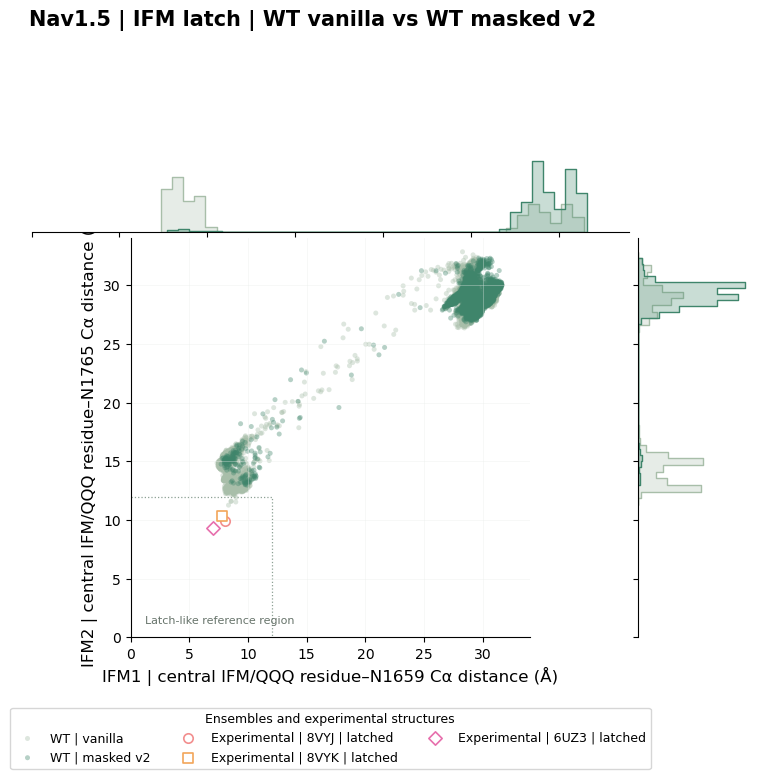

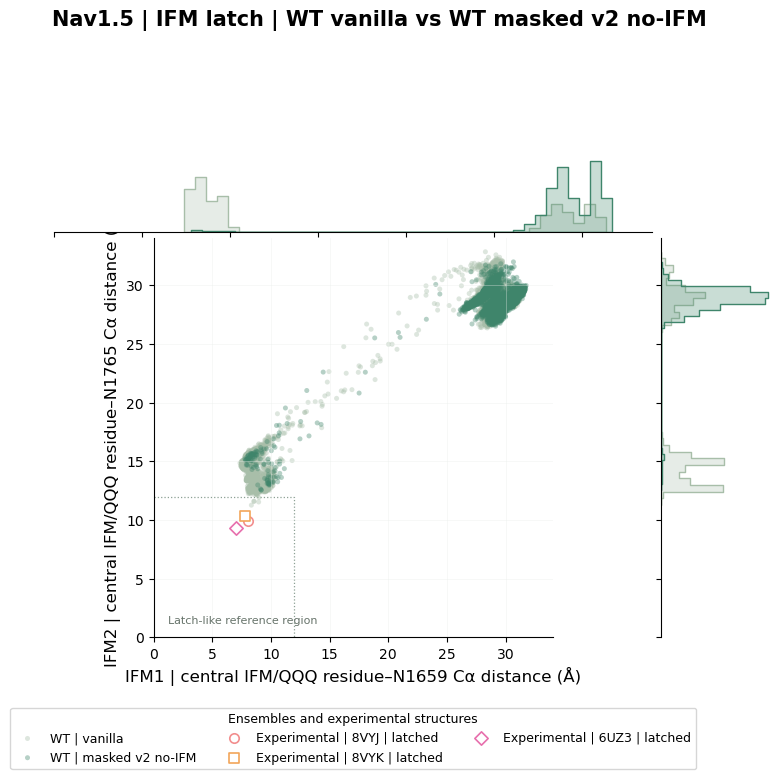

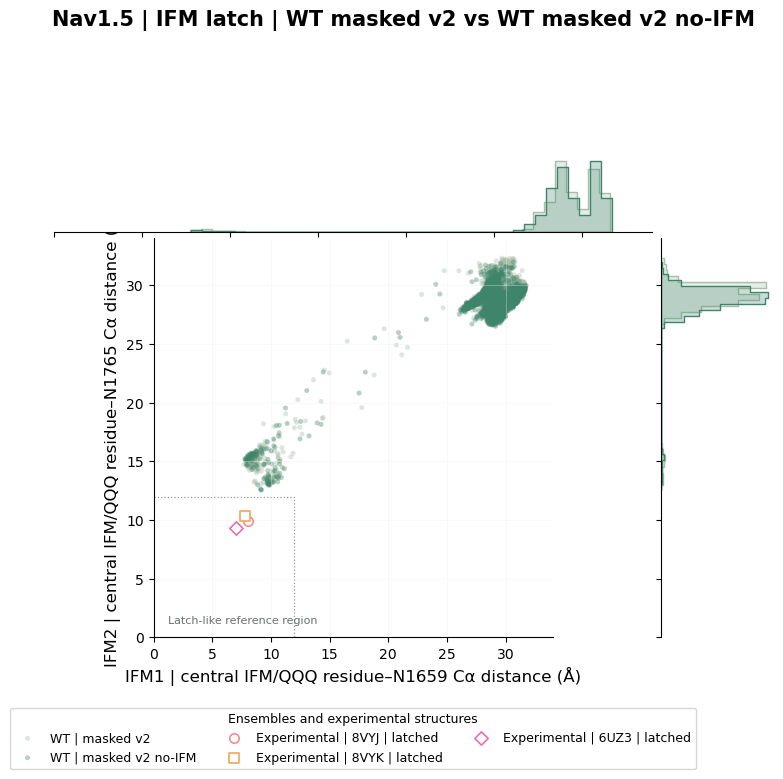

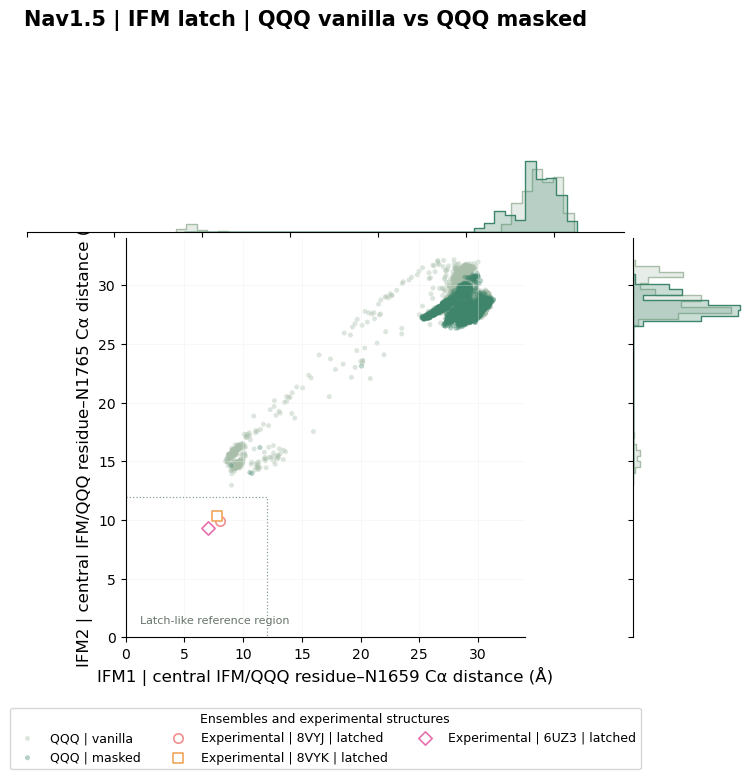

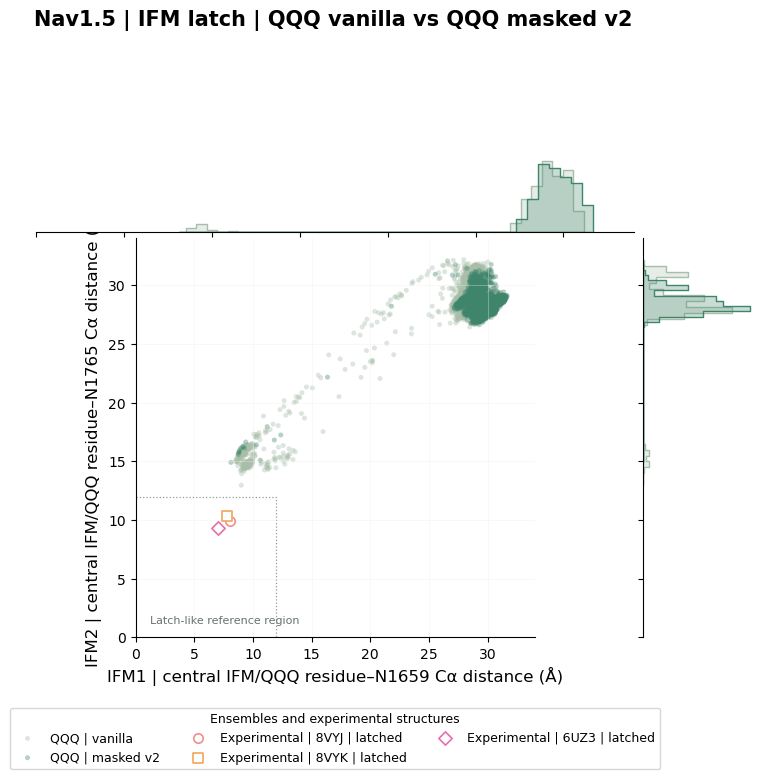

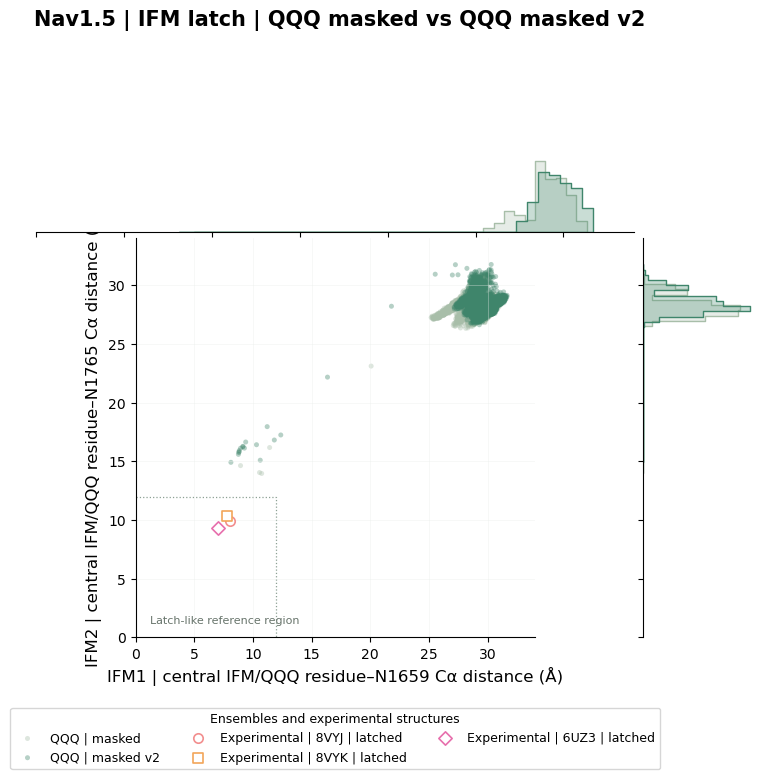

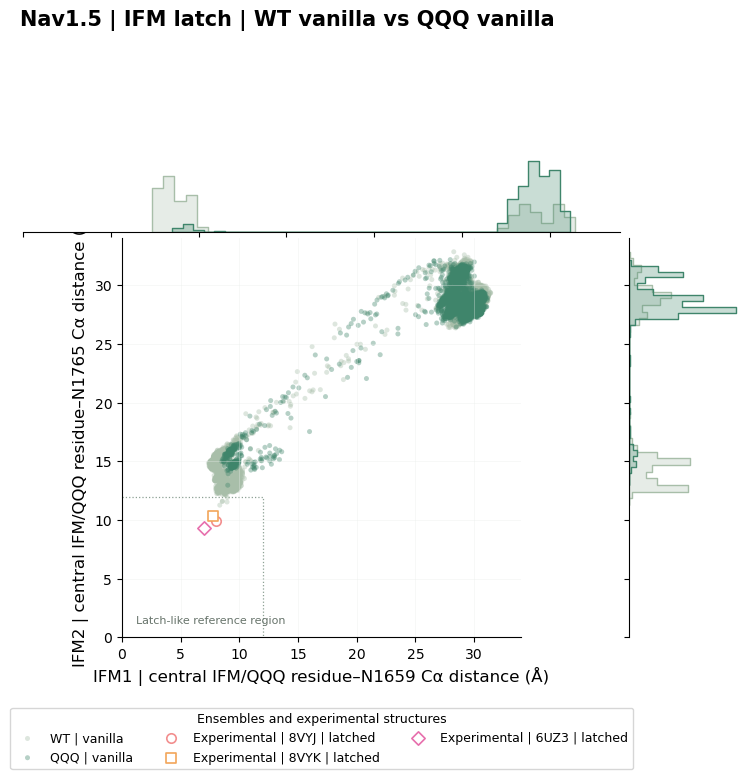

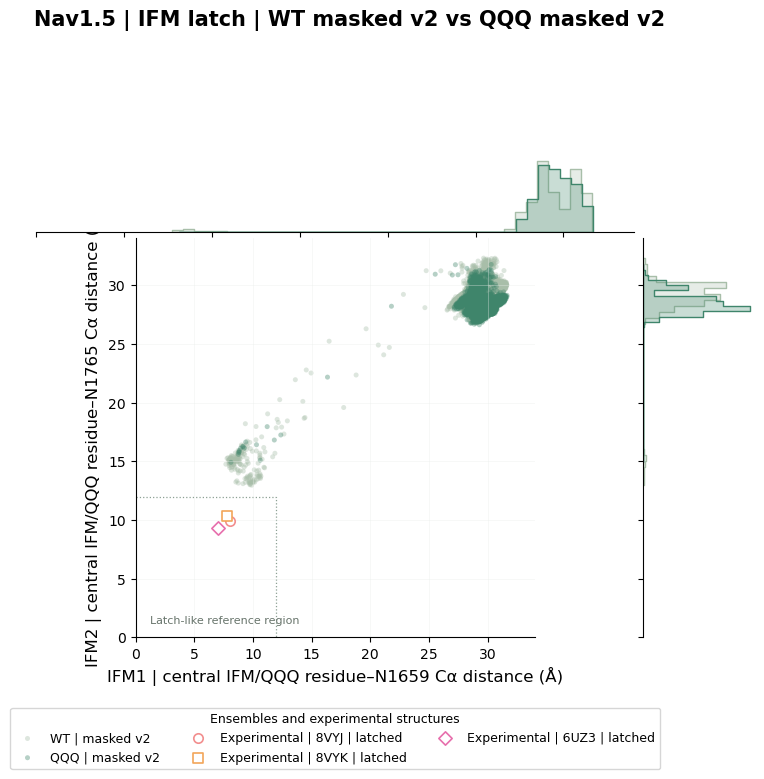

In [5]:
# 8VYJ/8VYK use canonical numbering. 6UZ3 is shifted +2 around this region.
EXPERIMENTAL_RESIDUE_MAP = {
    '8VYJ': {'IFM1': (('PHE',1486),('ASN',1659)), 'IFM2': (('PHE',1486),('ASN',1765))},
    '8VYK': {'IFM1': (('PHE',1486),('ASN',1659)), 'IFM2': (('PHE',1486),('ASN',1765))},
    '6UZ3': {'IFM1': (('PHE',1488),('ASN',1661)), 'IFM2': (('PHE',1488),('ASN',1767))},
}

def explicit_experimental_distances():
    result = {}
    for pdb_id, mapping in EXPERIMENTAL_RESIDUE_MAP.items():
        atoms = ca_atoms(repo_root/f'nav15/experimental/{pdb_id}.pdb')
        result[pdb_id] = {label: round(float(np.linalg.norm(atoms[a]-atoms[b])), 3) for label,(a,b) in mapping.items()}
    return result

# Explicit editable values (Å), calculated from the residue map above.
EXPERIMENTAL_IFM_DISTANCES = {
    '8VYJ': {'IFM1': 8.037, 'IFM2': 9.896},
    '8VYK': {'IFM1': 7.782, 'IFM2': 10.316},
    '6UZ3': {'IFM1': 7.028, 'IFM2': 9.304},
}
recalculated = explicit_experimental_distances()
for pdb_id, expected in EXPERIMENTAL_IFM_DISTANCES.items():
    for alias, expected_value in expected.items():
        assert np.isclose(recalculated[pdb_id][alias], expected_value, atol=0.001), (pdb_id, alias, recalculated[pdb_id][alias], expected_value)
EXPERIMENTAL_IFM_DISTANCES

# Overlay these reference points on both protocol plots if desired.
def plot_missing_af2_panel(protocol):
    fig, ax = plt.subplots(figsize=(7, 6))
    experimental_markers = ['o', 's', 'D', '^', 'v', 'P', 'X', '*']
    experimental_colors = ['#D55E00', '#0072B2', '#009E73', '#CC79A7']
    for i, (pdb_id, values) in enumerate(EXPERIMENTAL_IFM_DISTANCES.items()):
        ax.scatter(values['IFM1'], values['IFM2'], marker=experimental_markers[i % len(experimental_markers)], s=110, color=experimental_colors[i % len(experimental_colors)], edgecolor='white', linewidth=.7)
        ax.annotate(pdb_id, (values['IFM1'], values['IFM2']), xytext=(6,6), textcoords='offset points')
    ax.set_xlabel(f"IFM1 | {IFM_CONTACT_ALIASES['IFM1']['display_alias']} (Å)")
    ax.set_ylabel(f"IFM2 | {IFM_CONTACT_ALIASES['IFM2']['display_alias']} (Å)")
    ax.set_title(f'Nav1.5 | WT vs IFM→QQQ | {protocol} | IFM latching | {SUBSET}\nAF2 distributions unavailable — experimental references only')
    ax.text(.5, .08, 'Set PDB_ROOT_OVERRIDES to the AF2 PDB folders and rerun', transform=ax.transAxes, ha='center', color='#B22222', bbox={'facecolor':'white','edgecolor':'#B22222','alpha':.9})
    ax.grid(linestyle='--', linewidth=.4, alpha=.5)
    sns.despine(ax=ax); fig.tight_layout(); plt.show()

IFM_LATCH_COMPARISONS = [
    ('WT | vanilla', 'WT | masked v2'),
    ('WT | vanilla', 'WT | masked v2 no-IFM'),
    ('WT | masked v2', 'WT | masked v2 no-IFM'),
    ('QQQ | vanilla', 'QQQ | masked'),
    ('QQQ | vanilla', 'QQQ | masked v2'),
    ('QQQ | masked', 'QQQ | masked v2'),
    ('WT | vanilla', 'QQQ | vanilla'),
    ('WT | masked v2', 'QQQ | masked v2'),
]
for ensemble_a, ensemble_b in IFM_LATCH_COMPARISONS:
    plot_ifm_joint(ifm_df, ensemble_a, ensemble_b)


## Alternative receptor contacts to test
This audit ranks nonlocal Cα neighbors of canonical F1486 in 8VYJ. AF2 constructs use F1170 (or Q1170 for QQQ). Copy a receptor tuple into both condition entries only after mapping its canonical residue number to the construct sequence.


In [6]:
reference_atoms = ca_atoms(repo_root/'nav15/experimental/8VYJ.pdb')
ifm_key = ('PHE', 1486)
candidate_rows = []
for (resname, resid), xyz in reference_atoms.items():
    if abs(resid - 1486) <= 15:
        continue
    candidate_rows.append({'candidate_tuple': (resname, resid), 'CA_distance_to_F1486_A': float(np.linalg.norm(reference_atoms[ifm_key]-xyz))})
CONTACT_CANDIDATES = pd.DataFrame(candidate_rows).sort_values('CA_distance_to_F1486_A').head(30).reset_index(drop=True)
display(CONTACT_CANDIDATES)


,candidate_tuple,CA_distance_to_F1486_A
0,"(VAL, 1323)",5.929959
1,"(ALA, 1656)",5.932060
2,"(VAL, 1322)",6.141618
3,"(ALA, 1326)",7.751818
4,"(ASN, 1659)",8.037214
5,"(ALA, 1769)",8.300080
6,"(PRO, 1655)",8.759599
7,"(LEU, 1657)",8.799131
8,"(ILE, 1660)",8.971834
9,"(MET, 1320)",9.231052


## Shortest heavy-atom latch contacts

The Cα coordinates above are retained because they report the position of the motif backbone. The plots below add shortest heavy-atom distances, which are more sensitive to direct side-chain engagement. `Central–N1659` and `Central–N1765` use F1486 in WT or Q1486 in QQQ. `Whole motif–N1659` is the minimum distance from any IFM or QQQ residue to N1659. A short heavy-atom distance supports physical contact, but should be interpreted together with the two Cα coordinates rather than used as a stand-alone definition of latching.


In [ ]:
shortest_frames = []
for ensemble, path in DISTANCE_CSVS.items():
    condition, protocol = [part.strip() for part in ensemble.split('|', 1)]
    source = pd.read_csv(path)
    motif = ['ILE1169', 'PHE1170', 'MET1171'] if condition == 'WT' else ['GLN1169', 'GLN1170', 'GLN1171']
    central = motif[1]
    columns = {
        'Shortest central–N1659': f'shortest_{central}-ASN1343',
        'Shortest central–N1765': f'shortest_{central}-ASN1449',
    }
    motif_columns = [f'shortest_{residue}-ASN1343' for residue in motif]
    missing = [column for column in [*columns.values(), *motif_columns] if column not in source.columns]
    if missing:
        raise KeyError(f'{ensemble}: missing shortest latch columns {missing}')
    selected_columns = list(dict.fromkeys(['pdb_file', *columns.values(), *motif_columns]))
    frame = source[selected_columns].copy()
    frame['Shortest whole motif–N1659'] = frame[motif_columns].min(axis=1)
    frame = frame.rename(columns={value: key for key, value in columns.items()})
    frame.insert(0, 'Protocol', protocol)
    frame.insert(0, 'Condition', condition)
    frame.insert(0, 'Ensemble', ensemble)
    shortest_frames.append(frame[['Ensemble', 'Condition', 'Protocol', 'pdb_file', *columns.keys(), 'Shortest whole motif–N1659']])
shortest_ifm_df = pd.concat(shortest_frames, ignore_index=True)
display(shortest_ifm_df.groupby('Ensemble').agg(
    models=('pdb_file', 'size'),
    central_N1659_median=('Shortest central–N1659', 'median'),
    central_N1765_median=('Shortest central–N1765', 'median'),
    whole_motif_N1659_median=('Shortest whole motif–N1659', 'median'),
).round(2))


In [ ]:
def residue_heavy_atoms(pdb_path, chain='A'):
    residues = {}
    with open(pdb_path, errors='ignore') as handle:
        for line in handle:
            if not line.startswith('ATOM') or line[21].strip() != chain:
                continue
            atom_name = line[12:16].strip()
            element = line[76:78].strip() or atom_name[0]
            if element.upper() == 'H' or line[16] not in (' ', 'A'):
                continue
            key = (line[17:20].strip(), int(line[22:26]))
            residues.setdefault(key, []).append(np.array([float(line[30:38]), float(line[38:46]), float(line[46:54])]))
    return residues

def minimum_residue_distance(residues, keys_a, key_b):
    atoms_a = [xyz for key in keys_a for xyz in residues.get(key, [])]
    atoms_b = residues.get(key_b, [])
    if not atoms_a or not atoms_b:
        return np.nan
    a = np.vstack(atoms_a); b = np.vstack(atoms_b)
    return float(np.linalg.norm(a[:, None, :] - b[None, :, :], axis=2).min())

EXPERIMENTAL_SHORTEST_IFM_DISTANCES = {}
for pdb_id, mapping in EXPERIMENTAL_RESIDUE_MAP.items():
    residues = residue_heavy_atoms(repo_root/f'nav15/experimental/{pdb_id}.pdb')
    central_1, site_1 = mapping['IFM1']
    central_2, site_2 = mapping['IFM2']
    offset = central_1[1] - 1486
    motif = [('ILE', 1485 + offset), ('PHE', 1486 + offset), ('MET', 1487 + offset)]
    EXPERIMENTAL_SHORTEST_IFM_DISTANCES[pdb_id] = {
        'Shortest central–N1659': minimum_residue_distance(residues, [central_1], site_1),
        'Shortest central–N1765': minimum_residue_distance(residues, [central_2], site_2),
        'Shortest whole motif–N1659': minimum_residue_distance(residues, motif, site_1),
    }
pd.DataFrame(EXPERIMENTAL_SHORTEST_IFM_DISTANCES).T.round(2)


In [ ]:
def plot_shortest_latch_contacts(data, ensemble_a, ensemble_b):
    requested = [ensemble_a, ensemble_b]
    x = 'Shortest central–N1659'; y = 'Shortest central–N1765'
    part = data[data['Ensemble'].isin(requested)].dropna(subset=[x, y])
    colors = {ensemble_a: '#DCC9EA', ensemble_b: '#8056A6'}
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), gridspec_kw={'width_ratios': [1.08, 1]})
    ax = axes[0]
    for ensemble in requested:
        values = part[part['Ensemble'].eq(ensemble)]
        ax.scatter(values[x], values[y], s=14, alpha=.38, color=colors[ensemble], edgecolor='none', rasterized=True, label=ensemble)
    markers = ['o', 's', 'D']
    experimental_colors = ['#F28E8E', '#F2A65A', '#E76FAD']
    for i, (pdb_id, values) in enumerate(EXPERIMENTAL_SHORTEST_IFM_DISTANCES.items()):
        ax.scatter(values[x], values[y], marker=markers[i], s=38, facecolor='white', edgecolor=experimental_colors[i], linewidth=1.1, zorder=10, label=f'{pdb_id} latched')
    ax.set_xlabel('Central IFM/QQQ residue–N1659\nshortest heavy-atom distance (Å)')
    ax.set_ylabel('Central IFM/QQQ residue–N1765\nshortest heavy-atom distance (Å)')
    ax.grid(color='#EEE9F2', linewidth=.45, alpha=.65)

    long = part[['Ensemble', 'Shortest whole motif–N1659']].rename(columns={'Shortest whole motif–N1659': 'Distance'})
    sns.violinplot(data=long, x='Ensemble', y='Distance', order=requested, palette=colors, inner='quartile', cut=0, linewidth=.8, ax=axes[1])
    for i, (pdb_id, values) in enumerate(EXPERIMENTAL_SHORTEST_IFM_DISTANCES.items()):
        axes[1].scatter([-.10 + i*.10], [values['Shortest whole motif–N1659']], marker=markers[i], s=32, facecolor='white', edgecolor=experimental_colors[i], linewidth=1.0, zorder=10)
    axes[1].set_xlabel('Ensemble')
    axes[1].set_ylabel('Whole IFM/QQQ motif–N1659\nminimum heavy-atom distance (Å)')
    axes[1].tick_params(axis='x', rotation=18)
    axes[1].grid(axis='y', color='#EEE9F2', linewidth=.45, alpha=.65)
    fig.suptitle(f"Nav1.5 | shortest IFM-latch contacts | {ensemble_a.replace(' | ', ' ')} vs {ensemble_b.replace(' | ', ' ')}", x=.06, ha='left', fontsize=14, weight='bold')
    ax.legend(title='Ensembles and latched structures', loc='upper center', bbox_to_anchor=(1.03, -.25), ncol=3, fontsize=8, title_fontsize=8, frameon=True)
    sns.despine(fig=fig)
    fig.subplots_adjust(bottom=.30, top=.84, wspace=.34)
    plt.show()

for ensemble_a, ensemble_b in IFM_LATCH_COMPARISONS:
    plot_shortest_latch_contacts(shortest_ifm_df, ensemble_a, ensemble_b)


### Interpretation guardrail
A separated cluster can support sampling of different IFM-contact geometries, but neither Cα coordinates nor shortest contacts alone establish open-pore gating or causal electromechanical coupling. A latch-like assignment is strongest when the backbone coordinates and heavy-atom contacts agree. Check the intracellular gate and pore-radius coordinates alongside both representations before assigning an open state. The 7FBS QQQ structure does not contain resolved canonical IFM coordinates and is therefore not assigned fabricated experimental values.
